In [2]:
import xarray as xr

# path to the NetCDF file
data_path = "../data/LandsatKelpBiomass_2025_Q3_v2_withmetadata.nc"

# open dataset (this does NOT load everything into memory)
ds = xr.open_dataset(data_path)

ds


<xarray.Dataset> Size: 4GB
Dimensions:     (station: 594107, time: 167)
Coordinates:
  * time        (time) datetime64[ns] 1kB 1984-02-15 1984-05-15 ... 2025-08-15
Dimensions without coordinates: station
Data variables: (12/13)
    latitude    (station) float64 5MB ...
    longitude   (station) float64 5MB ...
    year        (time) int32 668B ...
    quarter     (time) int16 334B ...
    biomass     (time, station) float64 794MB ...
    biomass_se  (time, station) float64 794MB ...
    ...          ...
    area_se     (time, station) float64 794MB ...
    passes      (time, station) int16 198MB ...
    passes5     (time, station) int16 198MB ...
    passes7     (time, station) int16 198MB ...
    passes8     (time, station) int16 198MB ...
    passes6     (time, station) int16 198MB ...
Attributes: (12/50)
    title:                           SBC LTER: Time series of quarterly NetCD...
    summary:                         Wet biomass (kg) of giant kelp (Macrocys...
    keywords:                        biomass, canopy, LTER, populations, Sant...
    id:                              knb-lter-sbc.74.31
    doi:                             doi:10.6073/pasta/5b441f39c0876ef9010687...
    keywords_vocabulary:             LTER Controlled Vocabulary V1
    ...                              ...
    geospatial_vertical_resolution:  1
    time_coverage_start:             1984-01-1
    time_coverage_end:               2025-09-30
    time_coverage_duration:          P36Y
    time_coverage_resolution:        P3M
    metadata_link:                   https://portal.edirepository.org/nis/met...

Stations in full region: 114834
Stations in DEV subset: 2000


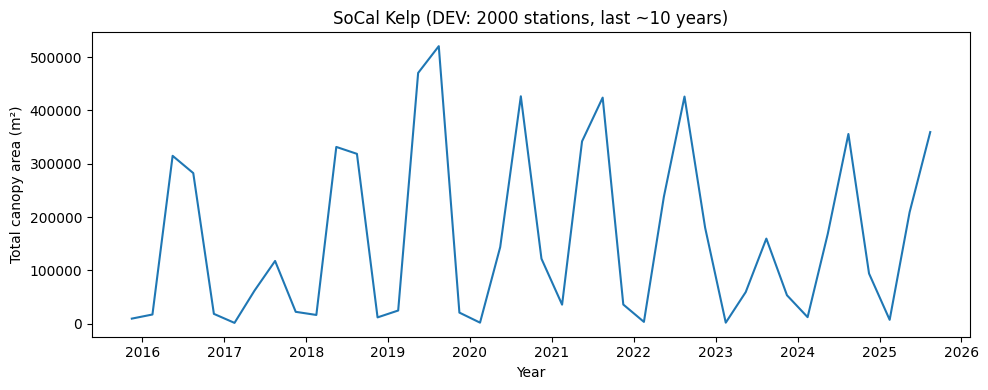

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# bbox
lat_min, lat_max = 33.8, 34.8
lon_min, lon_max = -120.8, -119.0

lat = ds["latitude"].values
lon = ds["longitude"].values

mask_np = (lat >= lat_min) & (lat <= lat_max) & (lon >= lon_min) & (lon <= lon_max)
stations_all = np.flatnonzero(mask_np)
print("Stations in full region:", stations_all.size)

# DEV: take a small subset (N stations)
N = 2000  # try 2000; increase later to 5000, 10000, etc.
stations_small = stations_all[:N]
print("Stations in DEV subset:", stations_small.size)

# DEV: also shorten time range to make it instant (last ~10 years)
sub = ds.isel(time=slice(-40, None), station=stations_small)

area_ts = sub["area"].sum(dim="station")

df_area = pd.DataFrame({
    "time": pd.to_datetime(sub["time"].values),
    "area_total": area_ts.values
}).set_index("time")

plt.figure(figsize=(10,4))
plt.plot(df_area.index, df_area["area_total"])
plt.title(f"SoCal Kelp (DEV: {N} stations, last ~10 years)")
plt.xlabel("Year")
plt.ylabel("Total canopy area (m²)")
plt.tight_layout()
plt.show()


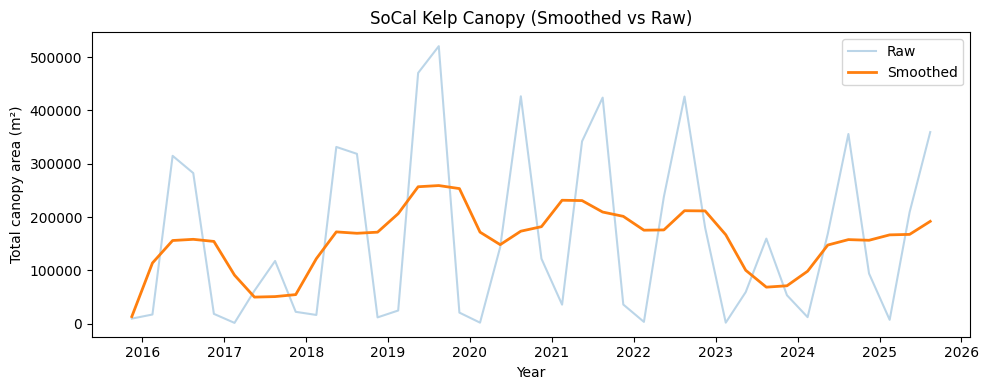

In [4]:
# Smooth with rolling mean (1 year = 4 quarters)
df_area["area_smooth"] = df_area["area_total"].rolling(
    window=4,
    center=True,
    min_periods=1
).mean()

plt.figure(figsize=(10,4))
plt.plot(df_area.index, df_area["area_total"], alpha=0.3, label="Raw")
plt.plot(df_area.index, df_area["area_smooth"], linewidth=2, label="Smoothed")
plt.title("SoCal Kelp Canopy (Smoothed vs Raw)")
plt.xlabel("Year")
plt.ylabel("Total canopy area (m²)")
plt.legend()
plt.tight_layout()
plt.show()


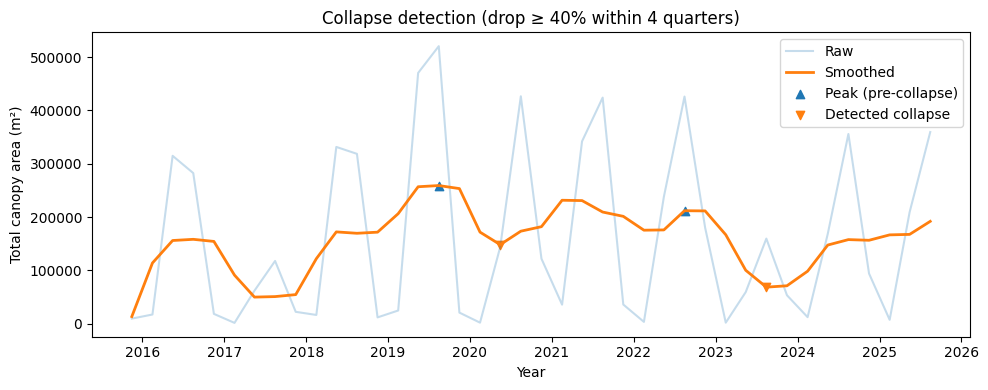

Detected collapses at: ['2020-05-15', '2023-08-15']


In [5]:
import numpy as np
import matplotlib.pyplot as plt

s = df_area["area_smooth"].copy()

# --- collapse definition (tunable knobs) ---
drop_frac = 0.40     # collapse = 40% drop
within_q = 4         # within 4 quarters (~1 year)
min_peak = s.quantile(0.60)  # only consider "real" peaks (ignore tiny peaks)

collapse_times = []
peak_times = []

# find simple local peaks (smoothed[t-1] < smoothed[t] > smoothed[t+1])
for i in range(1, len(s) - within_q - 1):
    if s.iloc[i-1] < s.iloc[i] and s.iloc[i] > s.iloc[i+1] and s.iloc[i] >= min_peak:
        peak_val = s.iloc[i]
        future_min = s.iloc[i+1:i+1+within_q].min()
        if future_min <= (1 - drop_frac) * peak_val:
            peak_times.append(s.index[i])
            # mark the time where the minimum occurs (collapse point)
            j = np.argmin(s.iloc[i+1:i+1+within_q].values)
            collapse_times.append(s.index[i+1+j])

# --- plot ---
plt.figure(figsize=(10,4))
plt.plot(df_area.index, df_area["area_total"], alpha=0.25, label="Raw")
plt.plot(df_area.index, df_area["area_smooth"], linewidth=2, label="Smoothed")

# peaks + collapses
plt.scatter(peak_times, s.loc[peak_times], marker="^", label="Peak (pre-collapse)")
plt.scatter(collapse_times, s.loc[collapse_times], marker="v", label="Detected collapse")

plt.title(f"Collapse detection (drop ≥ {int(drop_frac*100)}% within {within_q} quarters)")
plt.xlabel("Year")
plt.ylabel("Total canopy area (m²)")
plt.legend()
plt.tight_layout()
plt.show()

print("Detected collapses at:", [str(t.date()) for t in collapse_times])


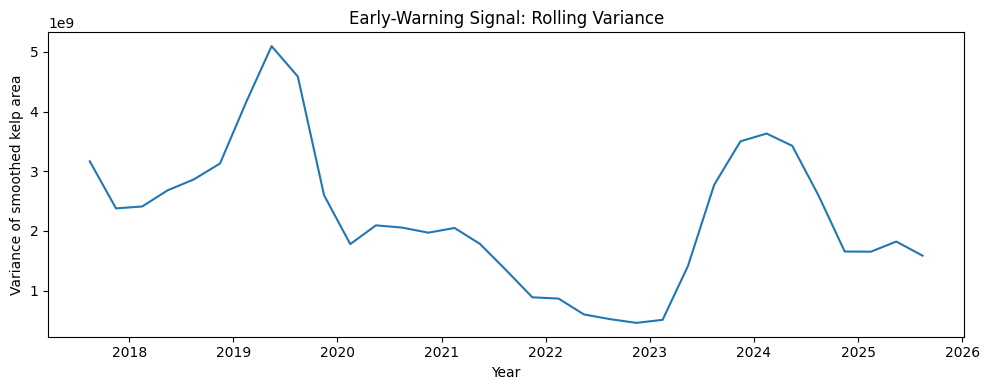

In [6]:
# -----------------------------
# Early-Warning Signal: Variance
# -----------------------------

# Use the smoothed kelp time series
x = df_area["area_smooth"]

# Rolling window (8 quarters = ~2 years)
window = 8

# Compute rolling variance
df_area["ews_variance"] = (
    x.rolling(window=window, min_periods=window)
     .var()
)

# Plot the early-warning signal
plt.figure(figsize=(10,4))
plt.plot(df_area.index, df_area["ews_variance"])
plt.title("Early-Warning Signal: Rolling Variance")
plt.xlabel("Year")
plt.ylabel("Variance of smoothed kelp area")
plt.tight_layout()
plt.show()


Stations in full region: 209398
Lon range in region: -120.730874629199 to -117.264930570808
Lat range in region: 32.8000210110737 to 34.746900879537


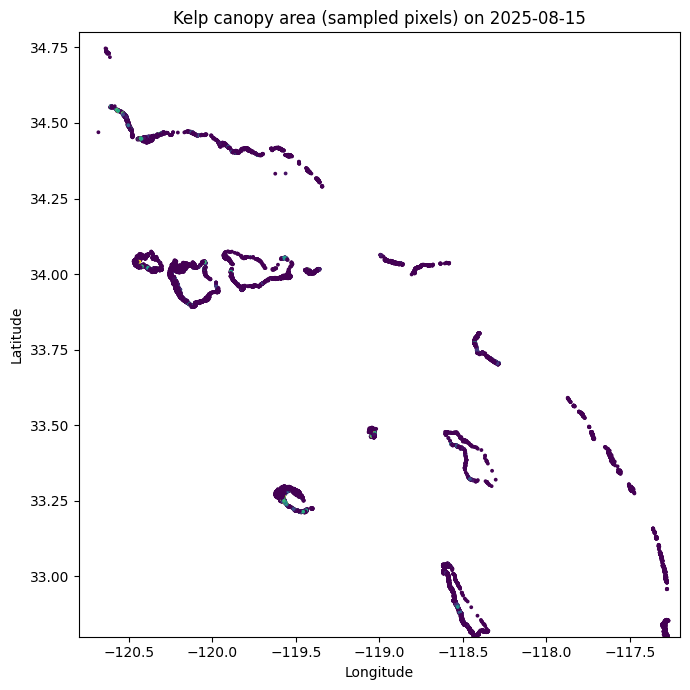

In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# -----------------------------
# 1) Better bbox (more mainland)
# -----------------------------
lat_min, lat_max = 32.8, 34.8
lon_min, lon_max = -120.8, -117.2   # moved east from -119.0 to -118.2

lat = ds["latitude"].values
lon = ds["longitude"].values

mask_np = (
    (lat >= lat_min) & (lat <= lat_max) &
    (lon >= lon_min) & (lon <= lon_max)
)

stations_all = np.flatnonzero(mask_np)
print("Stations in full region:", stations_all.size)
print("Lon range in region:", lon[stations_all].min(), "to", lon[stations_all].max())
print("Lat range in region:", lat[stations_all].min(), "to", lat[stations_all].max())

# -----------------------------
# 2) Random DEV sample (spatially representative)
# -----------------------------
N = 20000  # try 20k for a nice-looking map; lower if slow
rng = np.random.default_rng(0)
stations_small = rng.choice(stations_all, size=min(N, stations_all.size), replace=False)

sub_map = ds.isel(station=stations_small)

# pick a time (last quarter)
t = -1
area_t = sub_map["area"].isel(time=t).values
lat_s  = sub_map["latitude"].values
lon_s  = sub_map["longitude"].values
date_t = pd.to_datetime(sub_map["time"].values[t]).date()

# -----------------------------
# 3) Plot map
# -----------------------------
plt.figure(figsize=(7,7))
plt.scatter(lon_s, lat_s, c=area_t, s=3)
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title(f"Kelp canopy area (sampled pixels) on {date_t}")
plt.xlim(lon_min, lon_max)
plt.ylim(lat_min, lat_max)
plt.tight_layout()
plt.show()


In [8]:
import os
import urllib.request
import urllib.parse
import xarray as xr

# SoCal box
lat_min, lat_max = 33.8, 34.8
lon_min, lon_max = -120.8, -118.2

# ERDDAP uses 0..360 longitude
lon_min_0360 = lon_min % 360
lon_max_0360 = lon_max % 360

base = "https://coastwatch.pfeg.noaa.gov/erddap/griddap/ncdcOisst21Agg.nc"

def erddap_griddap_nc_url(var, start, end):
    # Correct ERDDAP constraint expression
    q = (
        f"{var}"
        f"[(%sT00:00:00Z):(%sT00:00:00Z)]"
        f"[(0)]"
        f"[({lat_min}):({lat_max})]"
        f"[({lon_min_0360}):({lon_max_0360})]"
    ) % (start, end)

    # URL-encode the query (keep ERDDAP special chars safe)
    safe = "[]():,._-TZabcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789"
    return base + "?" + urllib.parse.quote(q, safe=safe)

# ---- TEST: one year ----
url_test = erddap_griddap_nc_url("sst", "2020-01-01", "2020-12-31")
print("TEST URL:", url_test)

out_test = "oisst_socal_test_2020.nc"
urllib.request.urlretrieve(url_test, out_test)

print("Downloaded MB:", os.path.getsize(out_test)/1e6)

oisst_test = xr.open_dataset(out_test)
print(oisst_test)


TEST URL: https://coastwatch.pfeg.noaa.gov/erddap/griddap/ncdcOisst21Agg.nc?sst[(2020-01-01T00:00:00Z):(2020-12-31T00:00:00Z)][(0)][(33.8):(34.8)][(239.2):(241.8)]
Downloaded MB: 0.098496
<xarray.Dataset> Size: 91kB
Dimensions:    (time: 366, zlev: 1, latitude: 5, longitude: 12)
Coordinates:
  * time       (time) datetime64[ns] 3kB 2020-01-01T12:00:00 ... 2020-12-31T1...
  * zlev       (zlev) float32 4B 0.0
  * latitude   (latitude) float32 20B 33.88 34.12 34.38 34.62 34.88
  * longitude  (longitude) float32 48B 239.1 239.4 239.6 ... 241.4 241.6 241.9
Data variables:
    sst        (time, zlev, latitude, longitude) float32 88kB ...
Attributes: (12/46)
    cdm_data_type:              Grid
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    Conventions:                CF-1.6, ACDD-1.3, COARDS
    creator_email:              oisst-help@noaa.gov
    creator_name:               NOAA NCEI
    creator_type:               group
    ...                         .

In [9]:
# ---------------------------------------
# Convert daily SST grid → quarterly SST
# ---------------------------------------

import pandas as pd

# 1) Drop zlev (only surface) and average over space
sst_daily = (
    oisst_test["sst"]
    .isel(zlev=0)
    .mean(dim=("latitude", "longitude"))
)

# 2) Convert to pandas Series with datetime index
sst_daily = pd.Series(
    sst_daily.values,
    index=pd.to_datetime(oisst_test["time"].values),
    name="sst"
)

# 3) Aggregate daily → quarterly mean
sst_quarterly = sst_daily.resample("Q").mean()

# Check result
print(sst_quarterly.head())
print(sst_quarterly.tail())


2020-03-31    14.692436
2020-06-30    15.132311
2020-09-30    17.813278
2020-12-31    16.370268
Freq: QE-DEC, Name: sst, dtype: float32
2020-03-31    14.692436
2020-06-30    15.132311
2020-09-30    17.813278
2020-12-31    16.370268
Freq: QE-DEC, Name: sst, dtype: float32


/var/folders/61/3wm_gk5j5jvd7cv3mv31_8940000gn/T/ipykernel_95347/90876152.py:22: FutureWarning: 'Q' is deprecated and will be removed in a future version, please use 'QE' instead.
  sst_quarterly = sst_daily.resample("Q").mean()


Total files: 13
['oisst_socal_1984-01-01_1988-12-31.nc', 'oisst_socal_1989-01-01_1993-12-31.nc', 'oisst_socal_1994-01-01_1998-12-31.nc'] ... ['oisst_socal_2022-01-01_2023-12-31.nc', 'oisst_socal_2024-01-01_2025-12-31.nc', 'oisst_socal_test_2020.nc']
<xarray.Dataset> Size: 4MB
Dimensions:    (time: 14972, zlev: 1, latitude: 5, longitude: 12)
Coordinates:
  * time       (time) datetime64[ns] 120kB 1984-01-01T12:00:00 ... 2025-12-31...
  * zlev       (zlev) float32 4B 0.0
  * latitude   (latitude) float32 20B 33.88 34.12 34.38 34.62 34.88
  * longitude  (longitude) float32 48B 239.1 239.4 239.6 ... 241.4 241.6 241.9
Data variables:
    sst        (time, zlev, latitude, longitude) float32 4MB dask.array<chunksize=(1827, 1, 5, 12), meta=np.ndarray>
Attributes: (12/46)
    cdm_data_type:              Grid
    comment:                    Data was converted from NetCDF-3 to NetCDF-4 ...
    Conventions:                CF-1.6, ACDD-1.3, COARDS
    creator_email:              oisst-help@noaa.gov

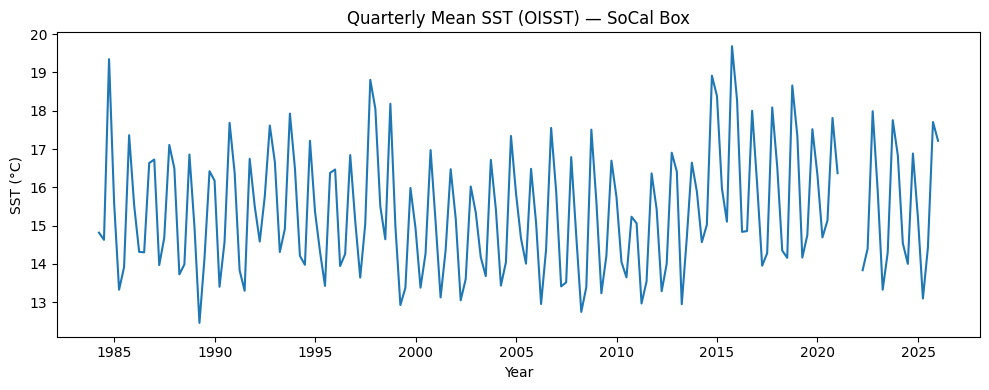

In [10]:
import glob
import xarray as xr
import pandas as pd
import matplotlib.pyplot as plt

# 1) Load all chunk files together
all_files = sorted(glob.glob("oisst_socal_*.nc"))
print("Total files:", len(all_files))
print(all_files[:3], "...", all_files[-3:])

oisst = xr.open_mfdataset(all_files, combine="by_coords")
print(oisst)

# 2) Regional mean SST per day (drop surface dimension)
sst_daily_da = (
    oisst["sst"]
    .isel(zlev=0)
    .mean(dim=("latitude", "longitude"))
)

# 3) Convert to pandas + resample daily -> quarterly mean
sst_daily = pd.Series(
    sst_daily_da.values,
    index=pd.to_datetime(oisst["time"].values),
    name="sst"
)

sst_quarterly = sst_daily.resample("QE").mean()

print("Quarterly SST:", sst_quarterly.index.min(), "to", sst_quarterly.index.max())
print(sst_quarterly.head())
print(sst_quarterly.tail())

# 4) Plot SST (sanity check)
plt.figure(figsize=(10,4))
plt.plot(sst_quarterly.index, sst_quarterly.values)
plt.title("Quarterly Mean SST (OISST) — SoCal Box")
plt.xlabel("Year")
plt.ylabel("SST (°C)")
plt.tight_layout()
plt.show()


Merged dataset rows (quarters): 36
                     kelp        sst  sst_anom
2015-12-31   13389.000000  18.277472  1.742689
2016-03-31  113893.333333  14.837722  0.749127
2016-06-30  156051.250000  14.858831  0.380270
2016-09-30  158276.750000  18.000154  0.176722
2016-12-31  154345.250000  16.061054 -0.473728

Using features:
Baseline: ['kelp_lag0', 'kelp_lag1', 'kelp_lag2', 'kelp_lag3', 'kelp_lag4']
Plus SST: ['kelp_lag0', 'kelp_lag1', 'kelp_lag2', 'kelp_lag3', 'kelp_lag4', 'sstanom_lag0', 'sstanom_lag1', 'sstanom_lag2', 'sstanom_lag3', 'sstanom_lag4', 'sstanom_mean4', 'sstanom_std4', 'sstanom_trend4']
Collapse threshold (next quarter): 64981.5

Best alpha (baseline): {'model__alpha': 0.1}
Best alpha (plus SST): {'model__alpha': 10.0}

REGRESSION — Baseline (kelp history only)
  MAE : 12606.466919654446
  RMSE: 15765.411993993026
  R^2 : 0.6464100917654434

REGRESSION — Plus SST anomaly features
  MAE : 66651.76606747977
  RMSE: 88895.03964606882
  R^2 : -10.2420177895239


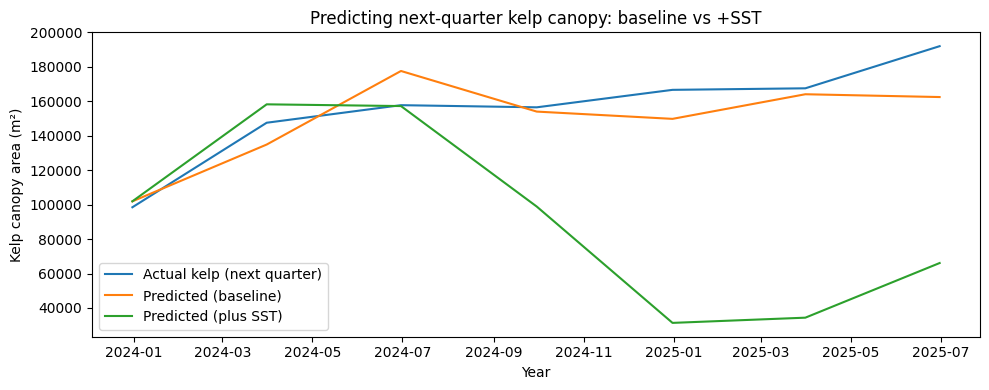


Top coefficients (absolute magnitude) — +SST model:
kelp_lag0         26315.044660
sstanom_lag1      14296.900577
sstanom_mean4     11011.437510
kelp_lag1          9827.832111
sstanom_std4      -8595.179269
sstanom_lag4      -5785.492006
sstanom_lag0       5465.026352
sstanom_lag2       4824.982194
kelp_lag3         -4783.771738
sstanom_trend4     3242.806050
kelp_lag4          2569.083610
sstanom_lag3        562.315273
dtype: float64


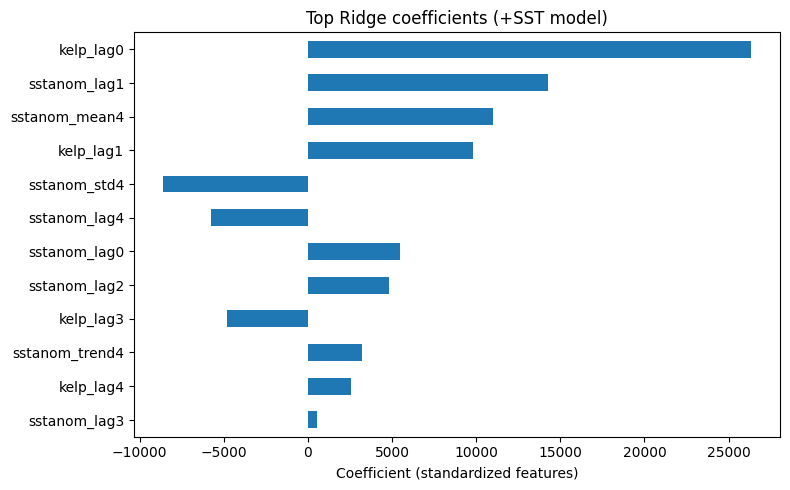


Best C (collapse classifier): {'model__C': 0.1}

Collapse classifier report (test):
              precision    recall  f1-score   support

           0       1.00      0.57      0.73         7
           1       0.00      0.00      0.00         0

    accuracy                           0.57         7
   macro avg       0.50      0.29      0.36         7
weighted avg       1.00      0.57      0.73         7

ROC AUC: not defined (test set has only one class)


/Users/tonylin/Documents/kelp_project/.venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/tonylin/Documents/kelp_project/.venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/tonylin/Documents/kelp_project/.venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/tonylin/Documents/kelp_project/.venv/lib/python3.14/site-packages/sklearn/metrics/_ranking.py:442: UndefinedMetricWarning: Only one class is present in y_true. ROC AUC score is not defined in that case.
  warnings.warn(
/Users/tonylin/Documents/kelp_project/.venv/lib/python3.14/site-packages/sklearn/metrics/_ra

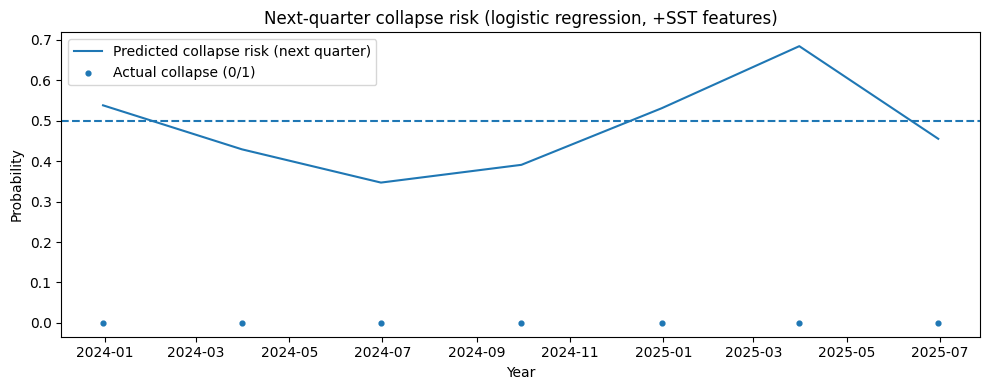

In [11]:
# ============================================================
# ML: Kelp canopy vs SST (time-series-safe, copy/paste ready)
# Requires: df_area (kelp quarterly) and sst_quarterly (quarterly SST)
# Output: regression + collapse-risk classification + plots
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---- check required variables exist ----
if "df_area" not in globals():
    raise NameError("I need df_area in memory (your kelp DataFrame). Run your kelp aggregation cells first.")
if "sst_quarterly" not in globals():
    raise NameError("I need sst_quarterly in memory (your SST quarterly Series). Run your OISST processing cells first.")

# ---- sklearn (preferred). If missing, install in your venv then restart kernel ----
try:
    from sklearn.pipeline import Pipeline
    from sklearn.preprocessing import StandardScaler
    from sklearn.linear_model import Ridge, LogisticRegression
    from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
    from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, roc_auc_score, classification_report
    SKLEARN_OK = True
except Exception as e:
    SKLEARN_OK = False
    raise ImportError(
        "This cell needs scikit-learn.\n"
        "Install it in your venv:\n"
        "  pip install scikit-learn\n\n"
        "If pip fails because you're on Python 3.14, create a Python 3.12 venv for sklearn.\n"
        f"Original import error: {type(e).__name__}: {e}"
    )

# ------------------------------------------------------------
# 1) Build a clean, quarter-aligned dataset: kelp + SST
# ------------------------------------------------------------

# Pick kelp column
kelp_col = "area_smooth" if "area_smooth" in df_area.columns else "area_total"

kelp = df_area[[kelp_col]].copy()
kelp.index = pd.to_datetime(kelp.index)

# Convert to quarter buckets (robust to slight timestamp differences)
kelp_q = kelp.groupby(kelp.index.to_period("Q")).mean()
kelp_q.index = kelp_q.index.to_timestamp("Q")  # quarter-end timestamps for plotting

sst = sst_quarterly.copy()
sst.index = pd.to_datetime(sst.index)
sst_q = sst.groupby(sst.index.to_period("Q")).mean()
sst_q.index = sst_q.index.to_timestamp("Q")

df = kelp_q.join(sst_q.rename("sst").to_frame(), how="inner").dropna()
df = df.rename(columns={kelp_col: "kelp"})

# Seasonal SST anomaly (removes expected Q1/Q2/Q3/Q4 season cycle)
df["sst_anom"] = df["sst"] - df.groupby(df.index.quarter)["sst"].transform("mean")

print("Merged dataset rows (quarters):", len(df))
print(df.head())

# ------------------------------------------------------------
# 2) Feature engineering (no leakage): use time t to predict t+1
# ------------------------------------------------------------
max_lag = 4   # use current + last 4 quarters (~1 year)
roll_win = 4  # 1-year rolling stats

# Kelp history features (baseline model)
for k in range(0, max_lag + 1):
    df[f"kelp_lag{k}"] = df["kelp"].shift(k)

# SST anomaly features (adds environment)
for k in range(0, max_lag + 1):
    df[f"sstanom_lag{k}"] = df["sst_anom"].shift(k)

df["sstanom_mean4"]  = df["sst_anom"].rolling(roll_win).mean()
df["sstanom_std4"]   = df["sst_anom"].rolling(roll_win).std()
df["sstanom_trend4"] = df["sst_anom"] - df["sst_anom"].shift(roll_win - 1)

# Target: predict next quarter kelp (t+1)
df["kelp_next"] = df["kelp"].shift(-1)

# Classification label: next-quarter collapse (below threshold)
baseline_level = df["kelp"].median()
collapse_frac = 0.40  # tweak later if you want
collapse_threshold = collapse_frac * baseline_level
df["collapse_next"] = (df["kelp_next"] < collapse_threshold).astype(int)

# Drop rows that have NA from lags/rolling/shift
df_ml = df.dropna().copy()

# Features
base_feats = [f"kelp_lag{k}" for k in range(0, max_lag + 1)]
sst_feats  = [f"sstanom_lag{k}" for k in range(0, max_lag + 1)] + ["sstanom_mean4", "sstanom_std4", "sstanom_trend4"]

X_base = df_ml[base_feats]
X_plus = df_ml[base_feats + sst_feats]
y_reg  = df_ml["kelp_next"]

print("\nUsing features:")
print("Baseline:", base_feats)
print("Plus SST:", base_feats + sst_feats)
print("Collapse threshold (next quarter):", float(collapse_threshold))

# ------------------------------------------------------------
# 3) Time-aware train/test split (NO SHUFFLE)
# ------------------------------------------------------------
split = int(len(df_ml) * 0.80)
Xb_train, Xb_test = X_base.iloc[:split], X_base.iloc[split:]
Xp_train, Xp_test = X_plus.iloc[:split], X_plus.iloc[split:]
y_train, y_test   = y_reg.iloc[:split],  y_reg.iloc[split:]

t_train = df_ml.index[:split]
t_test  = df_ml.index[split:]

# ------------------------------------------------------------
# 4) Regression ML: Ridge (baseline) vs Ridge(+SST)
# ------------------------------------------------------------
tscv = TimeSeriesSplit(n_splits=5)

ridge_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", Ridge())
])

param_grid = {"model__alpha": [0.1, 1.0, 10.0, 100.0, 1000.0]}

# Baseline model (kelp history only)
grid_base = GridSearchCV(
    ridge_pipe, param_grid,
    cv=tscv, scoring="neg_mean_absolute_error"
)
grid_base.fit(Xb_train, y_train)

# Plus-SST model
grid_plus = GridSearchCV(
    ridge_pipe, param_grid,
    cv=tscv, scoring="neg_mean_absolute_error"
)
grid_plus.fit(Xp_train, y_train)

pred_base = grid_base.predict(Xb_test)
pred_plus = grid_plus.predict(Xp_test)

def reg_metrics(y_true, y_pred, name):
    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))  # <- works on all sklearn versions
    r2   = r2_score(y_true, y_pred)
    print(f"\n{name}")
    print("  MAE :", mae)
    print("  RMSE:", rmse)
    print("  R^2 :", r2)


print("\nBest alpha (baseline):", grid_base.best_params_)
print("Best alpha (plus SST):", grid_plus.best_params_)

reg_metrics(y_test, pred_base, "REGRESSION — Baseline (kelp history only)")
reg_metrics(y_test, pred_plus, "REGRESSION — Plus SST anomaly features")

# Plot: actual vs predicted on test period
plt.figure(figsize=(10,4))
plt.plot(t_test, y_test.values, label="Actual kelp (next quarter)")
plt.plot(t_test, pred_base, label="Predicted (baseline)")
plt.plot(t_test, pred_plus, label="Predicted (plus SST)")
plt.title("Predicting next-quarter kelp canopy: baseline vs +SST")
plt.xlabel("Year")
plt.ylabel("Kelp canopy area (m²)")
plt.tight_layout()
plt.legend()
plt.show()

# Coefficients for the +SST ridge (interpretability)
best_plus = grid_plus.best_estimator_
coef = best_plus.named_steps["model"].coef_
coef_series = pd.Series(coef, index=Xp_train.columns).sort_values(key=np.abs, ascending=False)

print("\nTop coefficients (absolute magnitude) — +SST model:")
print(coef_series.head(12))

plt.figure(figsize=(8,5))
coef_series.head(12).iloc[::-1].plot(kind="barh")
plt.title("Top Ridge coefficients (+SST model)")
plt.xlabel("Coefficient (standardized features)")
plt.tight_layout()
plt.show()

# ------------------------------------------------------------
# 5) Classification ML: collapse risk next quarter (Logistic Regression)
# ------------------------------------------------------------
y_clf = df_ml["collapse_next"]
y_clf_train, y_clf_test = y_clf.iloc[:split], y_clf.iloc[split:]

# If test set has only one class, ROC AUC can't be computed. We'll still print what we can.
logit_pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=2000, class_weight="balanced"))
])

logit_grid = {
    "model__C": [0.1, 1.0, 10.0, 100.0]
}

grid_clf = GridSearchCV(
    logit_pipe, logit_grid,
    cv=tscv, scoring="roc_auc"
)
grid_clf.fit(Xp_train, y_clf_train)

proba = grid_clf.predict_proba(Xp_test)[:, 1]
pred  = (proba >= 0.5).astype(int)

print("\nBest C (collapse classifier):", grid_clf.best_params_)
print("\nCollapse classifier report (test):")
print(classification_report(y_clf_test, pred))

if y_clf_test.nunique() == 2:
    print("ROC AUC:", roc_auc_score(y_clf_test, proba))
else:
    print("ROC AUC: not defined (test set has only one class)")

# Plot collapse risk through time (test period)
plt.figure(figsize=(10,4))
plt.plot(t_test, proba, label="Predicted collapse risk (next quarter)")
plt.scatter(t_test, y_clf_test.values, label="Actual collapse (0/1)", s=12)
plt.axhline(0.5, linestyle="--")
plt.title("Next-quarter collapse risk (logistic regression, +SST features)")
plt.xlabel("Year")
plt.ylabel("Probability")
plt.tight_layout()
plt.legend()
plt.show()


df_area range: 1984-02-15 00:00:00 to 2025-08-15 00:00:00 rows: 167


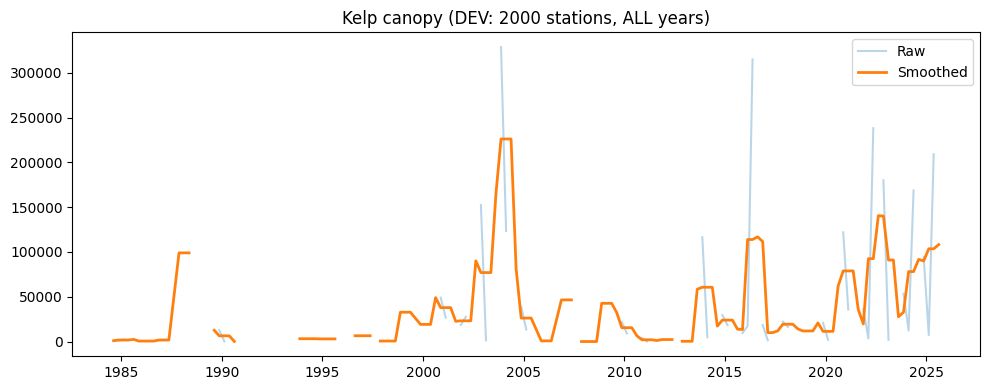

In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# keep same bbox + stations_all you already computed
N = 2000  # start small; scale up later
stations_small = stations_all[:N]

# ALL years (no time slice)
sub = ds.isel(station=stations_small)

# force load only what you need
area_vals = sub["area"].values  # shape: (time, station)
area_ts = area_vals.sum(axis=1)

df_area = pd.DataFrame({
    "time": pd.to_datetime(sub["time"].values),
    "area_total": area_ts
}).set_index("time").sort_index()

df_area["area_smooth"] = df_area["area_total"].rolling(4, center=True, min_periods=1).mean()

print("df_area range:", df_area.index.min(), "to", df_area.index.max(), "rows:", len(df_area))

plt.figure(figsize=(10,4))
plt.plot(df_area.index, df_area["area_total"], alpha=0.3, label="Raw")
plt.plot(df_area.index, df_area["area_smooth"], linewidth=2, label="Smoothed")
plt.title(f"Kelp canopy (DEV: {N} stations, ALL years)")
plt.legend()
plt.tight_layout()
plt.show()


Random stations: 5000
          area_total  valid_pixels
count     167.000000    167.000000
mean   160235.736527   4778.041916
std    146519.174229    579.816551
min         0.000000    451.000000
25%     60170.000000   4838.000000
50%    125476.000000   4969.000000
75%    208010.500000   4997.000000
max    814011.000000   5000.000000


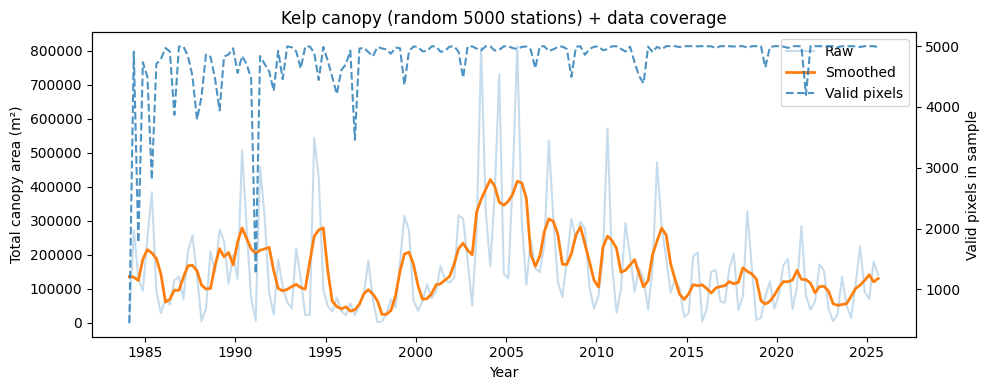

In [15]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- 1) RANDOM sample stations (important) ---
N = 5000  # start 5k; later 20k, 50k, 100k
rng = np.random.default_rng(42)
stations_small = rng.choice(stations_all, size=N, replace=False)
print("Random stations:", stations_small.size)

sub = ds.isel(station=stations_small)

# --- 2) NaN-safe regional sum ---
# sum(skipna=True) will ignore missing pixels per quarter
area_ts = sub["area"].sum(dim="station", skipna=True)

# Also compute coverage: how many pixels were valid each quarter?
valid_count = sub["area"].notnull().sum(dim="station")

df_area = pd.DataFrame({
    "time": pd.to_datetime(sub["time"].values),
    "area_total": area_ts.values,
    "valid_pixels": valid_count.values
}).set_index("time").sort_index()

# Smooth
df_area["area_smooth"] = df_area["area_total"].rolling(4, center=True, min_periods=1).mean()

print(df_area[["area_total","valid_pixels"]].describe())

# --- 3) Plot kelp + coverage ---
fig, ax1 = plt.subplots(figsize=(10,4))

ax1.plot(df_area.index, df_area["area_total"], alpha=0.25, label="Raw")
ax1.plot(df_area.index, df_area["area_smooth"], linewidth=2, label="Smoothed")
ax1.set_xlabel("Year")
ax1.set_ylabel("Total canopy area (m²)")
ax1.set_title(f"Kelp canopy (random {N} stations) + data coverage")

ax2 = ax1.twinx()
ax2.plot(df_area.index, df_area["valid_pixels"], linestyle="--", alpha=0.8, label="Valid pixels")
ax2.set_ylabel("Valid pixels in sample")

# combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper right")

plt.tight_layout()
plt.show()


Best alpha: {'model__alpha': 1000}
ΔKelp regression (SST-only features)
MAE: 13183.998967342042
RMSE: 23016.233761893858
R^2: -0.012062660291989546

Feature effects (standardized):
anom_std4      429.461622
anom_now       288.800446
anom_trend4    266.752420
anom_mean4     119.109267
dtype: float64


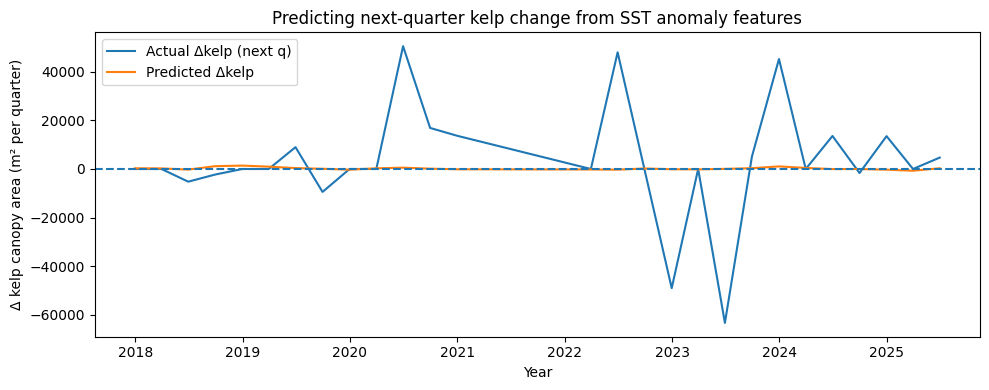

In [14]:
import numpy as np
import pandas as pd
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# ---- build aligned df (quarterly) ----
kelp_col = "area_smooth" if "area_smooth" in df_area.columns else "area_total"

kelp_q = df_area[[kelp_col]].copy()
kelp_q.index = pd.to_datetime(kelp_q.index)
kelp_q = kelp_q.groupby(kelp_q.index.to_period("Q")).mean()
kelp_q.index = kelp_q.index.to_timestamp("Q")

sst_q = sst_quarterly.to_frame("sst").copy()
sst_q.index = pd.to_datetime(sst_q.index)
sst_q = sst_q.groupby(sst_q.index.to_period("Q")).mean()
sst_q.index = sst_q.index.to_timestamp("Q")

df = kelp_q.join(sst_q, how="inner").dropna()
df = df.rename(columns={kelp_col: "kelp"})

# seasonal anomaly
df["sst_anom"] = df["sst"] - df.groupby(df.index.quarter)["sst"].transform("mean")

# ---- target: kelp change next quarter (more ML-friendly) ----
df["dkelp_next"] = df["kelp"].shift(-1) - df["kelp"]

# ---- compact SST features (low overfit) ----
df["anom_now"] = df["sst_anom"]
df["anom_mean4"] = df["sst_anom"].rolling(4).mean()
df["anom_std4"]  = df["sst_anom"].rolling(4).std()

# warming trend over last year
df["anom_trend4"] = df["sst_anom"] - df["sst_anom"].shift(3)

df_ml = df.dropna().copy()

X = df_ml[["anom_now", "anom_mean4", "anom_std4", "anom_trend4"]]
y = df_ml["dkelp_next"]

# time split
split = int(len(df_ml) * 0.8)
X_train, X_test = X.iloc[:split], X.iloc[split:]
y_train, y_test = y.iloc[:split], y.iloc[split:]

# ridge with time-series CV
pipe = Pipeline([("scaler", StandardScaler()), ("model", Ridge())])
grid = GridSearchCV(
    pipe,
    {"model__alpha": [0.1, 1, 10, 100, 1000]},
    cv=TimeSeriesSplit(n_splits=5),
    scoring="neg_mean_absolute_error"
)
grid.fit(X_train, y_train)

pred = grid.predict(X_test)

mae = mean_absolute_error(y_test, pred)
rmse = np.sqrt(mean_squared_error(y_test, pred))
r2 = r2_score(y_test, pred)

print("Best alpha:", grid.best_params_)
print("ΔKelp regression (SST-only features)")
print("MAE:", mae)
print("RMSE:", rmse)
print("R^2:", r2)

# interpret coefficients
best = grid.best_estimator_
coef = pd.Series(best.named_steps["model"].coef_, index=X.columns).sort_values(key=np.abs, ascending=False)
print("\nFeature effects (standardized):")
print(coef)

# quick plot
import matplotlib.pyplot as plt
t_test = df_ml.index[split:]

plt.figure(figsize=(10,4))
plt.plot(t_test, y_test.values, label="Actual Δkelp (next q)")
plt.plot(t_test, pred, label="Predicted Δkelp")
plt.axhline(0, linestyle="--")
plt.title("Predicting next-quarter kelp change from SST anomaly features")
plt.xlabel("Year")
plt.ylabel("Δ kelp canopy area (m² per quarter)")
plt.tight_layout()
plt.legend()
plt.show()


First decade mean: 155202.375
Last decade mean : 107737.13333333333
Percent change (last vs first decade): -30.58280626611975 %


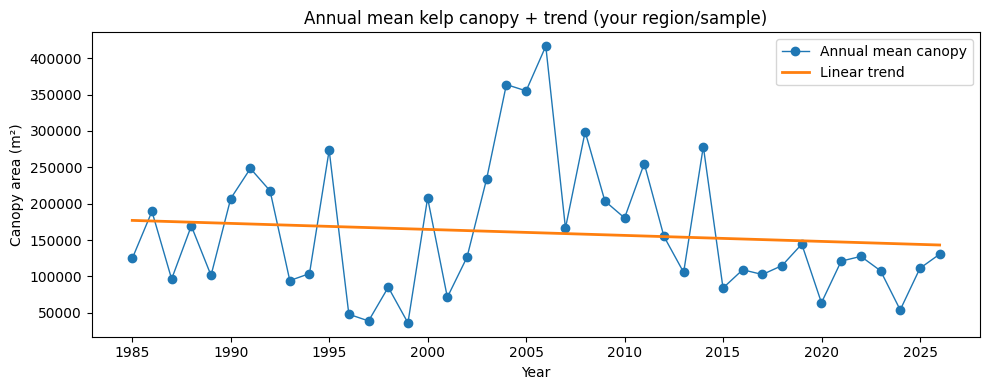

In [16]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1) Annual mean to reduce seasonal noise
annual = df_area["area_total"].resample("YE").mean()

# 2) Fit a simple linear trend
x = np.arange(len(annual))
y = annual.values

m, b = np.polyfit(x, y, 1)  # slope per year-step
trend = m*x + b

# 3) Percent change from first decade to last decade (more meaningful than endpoints)
first_dec = annual.iloc[:10].mean()
last_dec  = annual.iloc[-10:].mean()
pct_change = (last_dec - first_dec) / first_dec * 100

print("First decade mean:", first_dec)
print("Last decade mean :", last_dec)
print("Percent change (last vs first decade):", pct_change, "%")

# 4) Plot
plt.figure(figsize=(10,4))
plt.plot(annual.index, annual.values, marker="o", linewidth=1, label="Annual mean canopy")
plt.plot(annual.index, trend, linewidth=2, label="Linear trend")
plt.title("Annual mean kelp canopy + trend (your region/sample)")
plt.xlabel("Year")
plt.ylabel("Canopy area (m²)")
plt.tight_layout()
plt.legend()
plt.show()


In [ ]:
import numpy as np
import pandas as pd

# -------- SETTINGS (edit these only) --------
N = 5000  # DEV sample size (increase later)
SEED = 42
KELP_SMOOTH_WIN = 4  # 1 year = 4 quarters
# -------------------------------------------

# 1) random stations + kelp aggregation
rng = np.random.default_rng(SEED)
stations_small = rng.choice(stations_all, size=N, replace=False)

sub = ds.isel(station=stations_small)

kelp_area = sub["area"].sum(dim="station", skipna=True)
coverage = sub["area"].notnull().sum(dim="station")

df_kelp = pd.DataFrame({
    "time": pd.to_datetime(sub["time"].values),
    "kelp_area": kelp_area.values,
    "coverage": coverage.values
}).set_index("time").sort_index()

df_kelp["kelp_smooth"] = df_kelp["kelp_area"].rolling(
    window=KELP_SMOOTH_WIN, center=True, min_periods=1
).mean()

# 2) quarter-align SST and compute anomaly
sst_q = sst_quarterly.copy()
sst_q.index = pd.to_datetime(sst_q.index)
sst_q = sst_q.groupby(sst_q.index.to_period("Q")).mean()
sst_q.index = sst_q.index.to_timestamp("Q")
df_sst = sst_q.to_frame("sst")

df_sst["sst_anom"] = df_sst["sst"] - df_sst.groupby(df_sst.index.quarter)["sst"].transform("mean")

# 3) quarter-align kelp and merge
df_kelp_q = df_kelp.groupby(df_kelp.index.to_period("Q")).mean()
df_kelp_q.index = df_kelp_q.index.to_timestamp("Q")

df_combo = df_kelp_q.join(df_sst, how="inner").dropna()

print("df_combo rows:", len(df_combo))
print("range:", df_combo.index.min(), "to", df_combo.index.max())
print(df_combo.head())

# 4) save so you don't recompute
out_csv = f"analysis_table_kelp_sst_DEV_N{N}.csv"
df_combo.to_csv(out_csv)
print("Saved:", out_csv)
